In [10]:
import os, getpass

def _set_env(var: str):
    # Check if the variable is set in the OS environment
    env_value = os.environ.get(var)
    if not env_value:
        # If not set, prompt the user for input
        env_value = getpass.getpass(f"{var}: ")
    
    # Set the environment variable for the current process
    os.environ[var] = env_value

_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_WORKSPACE_ID"] = ""

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph , START , END , MessagesState



f:\AI ML\myvenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# Create LLM 
llm = ChatGoogleGenerativeAI(
    model="gemini-3.1-flash-lite",

)

ValidationError: 1 validation error for ChatGoogleGenerativeAI
  Value error, API key required for Gemini Developer API. Provide api_key parameter or set GOOGLE_API_KEY/GEMINI_API_KEY environment variable. [type=value_error, input_value={'model': 'gemini-3.1-fla...te', 'model_kwargs': {}}, input_type=dict]
    For further information visit https://errors.pydantic.dev/2.12/v/value_error

In [4]:
def call_model(state : MessagesState):
    return {
        "messages" : llm.invoke(state['messages'])
    }

In [5]:
builder = StateGraph(MessagesState)
builder.add_node('call_model' , call_model)
builder.add_edge(START , 'call_model')
builder.add_edge('call_model' , END)


In [6]:
agent = builder.compile()

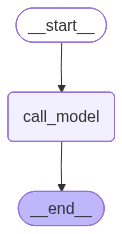

In [7]:
agent

In [8]:
agent.invoke({"messages" :"How r u GPT "})

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'messages': [HumanMessage(content='How r u GPT ', additional_kwargs={}, response_metadata={}, id='6692be53-4a78-43d0-80e8-ed3ae464b24f'),
  AIMessage(content=[{'type': 'text', 'text': "I'm doing great, thank you for asking! How are you doing today? Is there anything I can help you with?", 'extras': {'signature': 'EjQKMgEMOdbHotJRcAs+N3R85PCfwajUN8x1g+wazsfxlQIeFX7AvLNFopNRIS8QGG1l3PIK'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019ea82f-7b04-7d23-b9b7-fe42a59ed2d0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 6, 'output_tokens': 26, 'total_tokens': 32, 'input_token_details': {'cache_read': 0}})]}

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
